## Objectives of this notebook:
* Demonstrate plotting 3 dimensional data with colorblind templates for easy access to colorblind individuals.

* Demonstration of fixing bad and unnactractive charts which are less appealing for stakeholders.

* Multivariate Data Visualization
  * CCN
  * CNN
  * NNN
* Joint plot
* Pairplot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading the dataset
data = pd.read_csv('datasets/vgsales.csv')
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,2061,1942,NES,1985.0,Shooter,Capcom,4.569217,3.033887,3.439352,1.991671,12.802935
1,9137,¡Shin Chan Flipa en colores!,DS,2007.0,Platform,505 Games,2.076955,1.493442,3.033887,0.394830,7.034163
2,14279,.hack: Sekai no Mukou ni + Versus,PS3,2012.0,Action,Namco Bandai Games,1.145709,1.762339,1.493442,0.408693,4.982552
3,8359,.hack//G.U. Vol.1//Rebirth,PS2,2006.0,Role-Playing,Namco Bandai Games,2.031986,1.389856,3.228043,0.394830,7.226880
4,7109,.hack//G.U. Vol.2//Reminisce,PS2,2006.0,Role-Playing,Namco Bandai Games,2.792725,2.592054,1.440483,1.493442,8.363113


If you remember, `Genres`, `Publisher` and `Platform` were categorical values.

Hence similar to [matplotlib-for-beginners](https://github.com/aksharma-15/matplotlib-for-beginners.git), we will use top 3 of each to make our analysis easier.

In [4]:
top3_pub = data['Publisher'].value_counts().index[:3]
top3_gen = data['Genre'].value_counts().index[:3]
top3_plat = data['Platform'].value_counts().index[:3]

top3_data = data.loc[(data['Publisher'].isin(top3_pub)) & (data['Platform'].isin(top3_plat)) & (data['Genre'].isin(top3_gen))]
top3_data

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
2,14279,.hack: Sekai no Mukou ni + Versus,PS3,2012.0,Action,Namco Bandai Games,1.145709,1.762339,1.493442,0.408693,4.982552
13,2742,[Prototype 2],PS3,2012.0,Action,Activision,3.978349,3.727034,0.848807,2.792725,11.447989
16,1604,[Prototype],PS3,2009.0,Action,Activision,4.569217,4.108402,1.187272,3.339269,13.181205
19,1741,007: Quantum of Solace,PS3,2008.0,Action,Activision,4.156030,4.346074,1.087977,3.390562,12.980643
21,4501,007: Quantum of Solace,PS2,2008.0,Action,Activision,3.228043,2.738800,2.585598,3.652926,11.780257
...,...,...,...,...,...,...,...,...,...,...,...
16438,14938,Yes! Precure 5 Go Go Zenin Shu Go! Dream Festival,DS,2008.0,Action,Namco Bandai Games,1.087977,0.592445,1.087977,0.394830,3.509168
16479,10979,Young Justice: Legacy,PS3,2013.0,Action,Namco Bandai Games,2.186589,1.087977,3.409089,0.394830,7.359902
16601,11802,ZhuZhu Pets: Quest for Zhu,DS,2011.0,Misc,Activision,2.340740,1.525543,3.103825,0.394830,7.372592
16636,9196,Zoobles! Spring to Life!,DS,2011.0,Misc,Activision,2.697415,1.087977,2.760718,0.394830,6.915540


## Multivariate Data Visualization

Let's try to add a 3rd variable on the top of the plots that we have seen so far.

### NNC

**How can we visualize the correlation between NA and EU, but for different genres?**

Here, we have two numerical and one categorical variable!

- Numerical-Numerical $\rightarrow$ Scatter plot, need to add info about one categorical variable.
- Numerical-Categorical $\rightarrow$ Boxplot, need to add info about one numerical variable.

Let's ask two questions.
- Is it possible to add information about a continuous variable upon boxplots?
  - No
- Is it possible to add information about a categorical variable on scatterplot?
  - Yes (using colors)

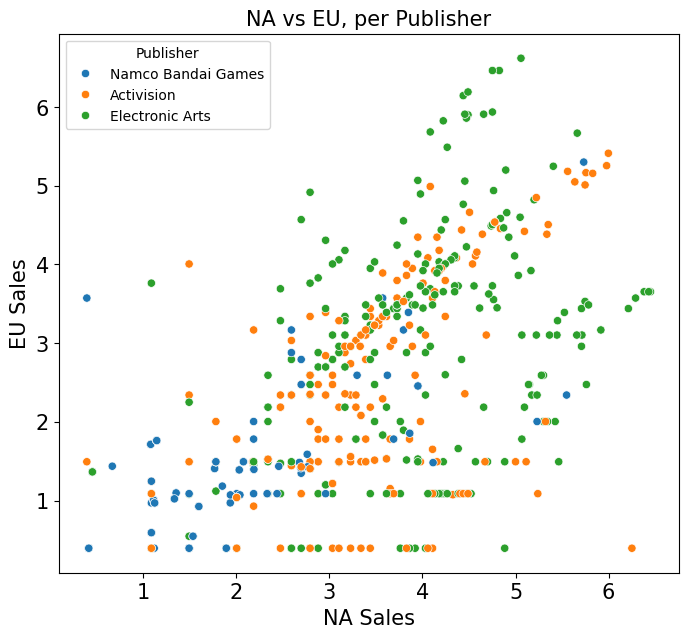

In [15]:
plt.figure(figsize = (8, 7))
sns.scatterplot(x = 'NA_Sales', y ='EU_Sales', hue = 'Publisher', data = top3_data)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('NA Sales',fontsize=15)
plt.ylabel('EU Sales',fontsize=15)
plt.title('NA vs EU, per Publisher', fontsize=15)
plt.show()

**Inferences:**

- If we see this plot, we can notice now that Namco has lower sales correlation, while Activision has a concentrated positive correlation.
- EA also has positive correlation, but it's more spread compared to Activision.

### CCN

**How will you visualize the global sales for each publisher, but separated by genres?**

We have two categorical and one numerical data here!

- Categorical-Categorical $\rightarrow$ Stacked Bar plot, need to add info about one continuous feature.
- Categorical-Numerical $\rightarrow$ Boxplot, need to add categorical variable.

**Which one is easier and possible?**

We can add one categorical variable by “dodging” multiple boxplots.

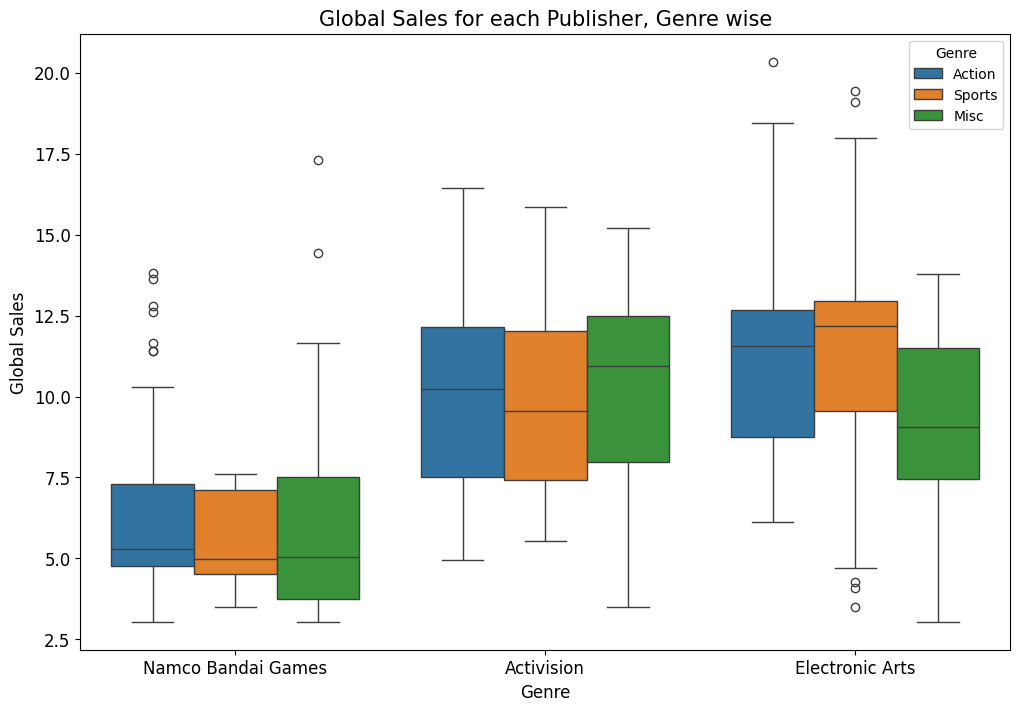

In [16]:
plt.figure(figsize = (12, 8))
sns.boxplot(x = 'Publisher', y = 'Global_Sales', hue = 'Genre', data = top3_data)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Global Sales', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Global Sales for each Publisher, Genre wise', fontsize=15)
plt.show()

**Inferences:**

- Namco has lower median sales in every genre as compared to all publishers.
- Looking at the Action genre, even though EA and Activision have almost similar medians, Action is more spread in EA.
- An interesting thing to notice here is that for each of the three publishers, three different genre of games have higher sales median.
  - Namco: Action
  - Activision: Misc
  - EA: Sports

### NNN

So far we have seen how NA and EU are correlated with each other.

But how can we compare the data when we have 3 numerical variables?

**How does rank affect the correlation between NA and JP Sales?**

We have used scatter plot for two numerical features.

We have two options here -

- Make a 3D Scatterplot
  - Good for 3D visualization, but tough to report/show in static setting.
- Add info about the 3rd feature on the 2D scatter plot itself.
  - Bubble Chart

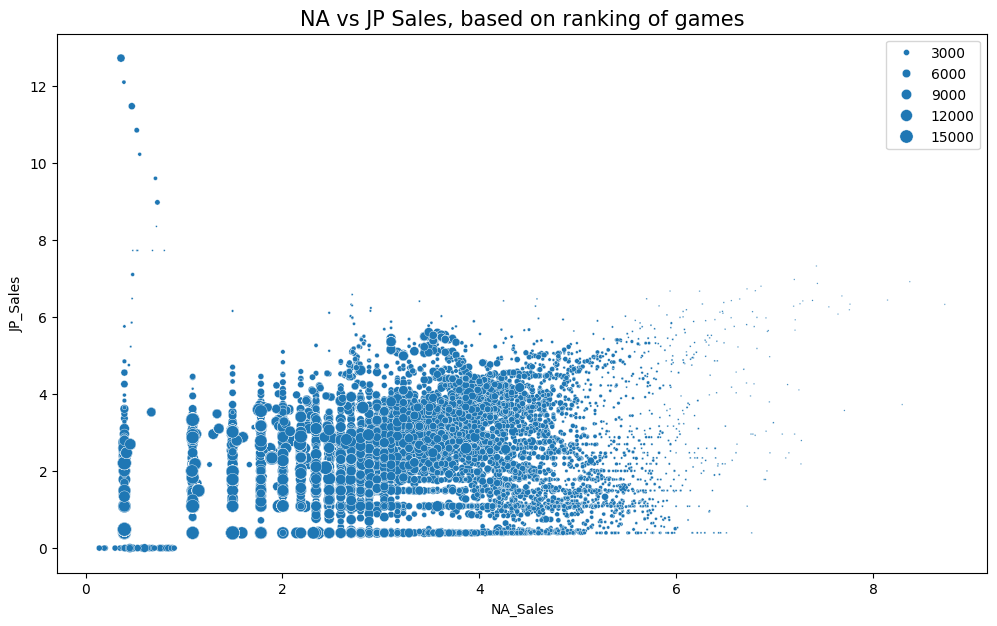

In [21]:
plt.figure(figsize = (12, 7))
sns.scatterplot(x = 'NA_Sales', y = 'JP_Sales', size = 'Rank', sizes = (1, 100), data = data)
plt.xlabel('NA_Sales',fontsize=10)
plt.ylabel('JP_Sales', fontsize=10)
plt.title('NA vs JP Sales, based on ranking of games', fontsize=15)
plt.legend(loc = 'upper right')
plt.show()

**Inferences:**

- Interestingly, we can notice that higher ranking games are actually on the lower scale of sales, while lower ranking games are high on the sales side.

# Joint Plot

- `jointplot()` draws a plot between two variables.
- It shows scatter plot, histogram and KDE plot in the same plot.

Let's check it out -

- We will take **`NA_Sales` as x-coordinates** and **`EU_Sales` as y-coordinates**.
- We can select from different values for parameter `kind and it will plot accordingly.
  - "scatter" | "kde" | "hist" | "hex" | "reg" | "resid"

- We will set the `kind` parameter to **'reg'** here.

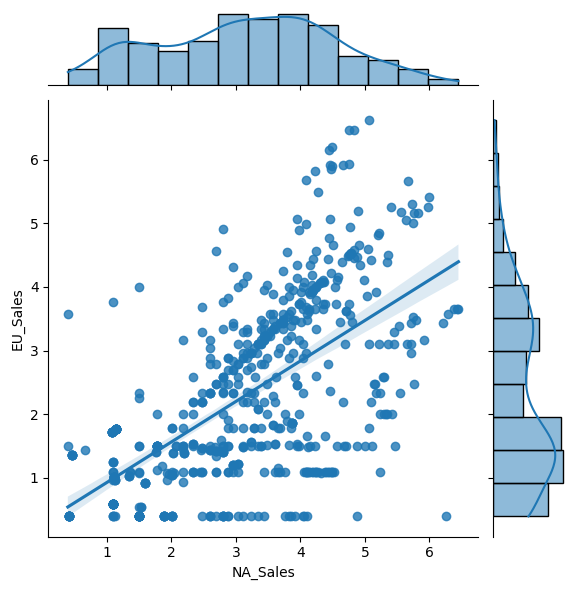

In [24]:
sns.jointplot(x = 'NA_Sales', y = 'EU_Sales', kind = 'reg', data = top3_data)
plt.show()

As we can see here,
- `jointplot` plots scatter plot, histogram and KDE plot in the same graph, when we set `kind=reg`.
- Scatter plot shows the **scattering of (`NA_Sales`, `EU_Sales`) pairs as (x, y) points**.
- Histogram and KDE plot show the separate distributions of `NA_Sales` and `EU_Sales` in the data.

**We can also add hue to Joint plot.**

Let's check how the 3 genres of games are distributed in terms of `NA_Sales` and `EU_Sales`.

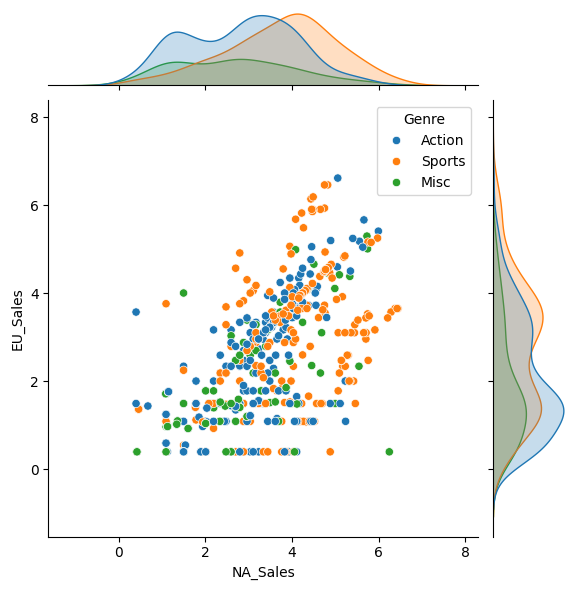

In [25]:
sns.jointplot(x = 'NA_Sales', y = 'EU_Sales', data = top3_data, hue = 'Genre')
plt.show()

# Pair Plot

### Pair Plot

- `pairplot()` creates a **grid of Axes by default**.
- Each numeric attribute in `data` is shared across **the y-axes across a single row** and the **x-axes across a single column**.
- It displays a **scatterplot between each pair of attributes in the data** with different **hue** for each category.

Since the diagonal plots belong to same attribute at both x and y axis, they are treated differently.

A univariate distribution plot is drawn to show the marginal distribution of the data in each column.

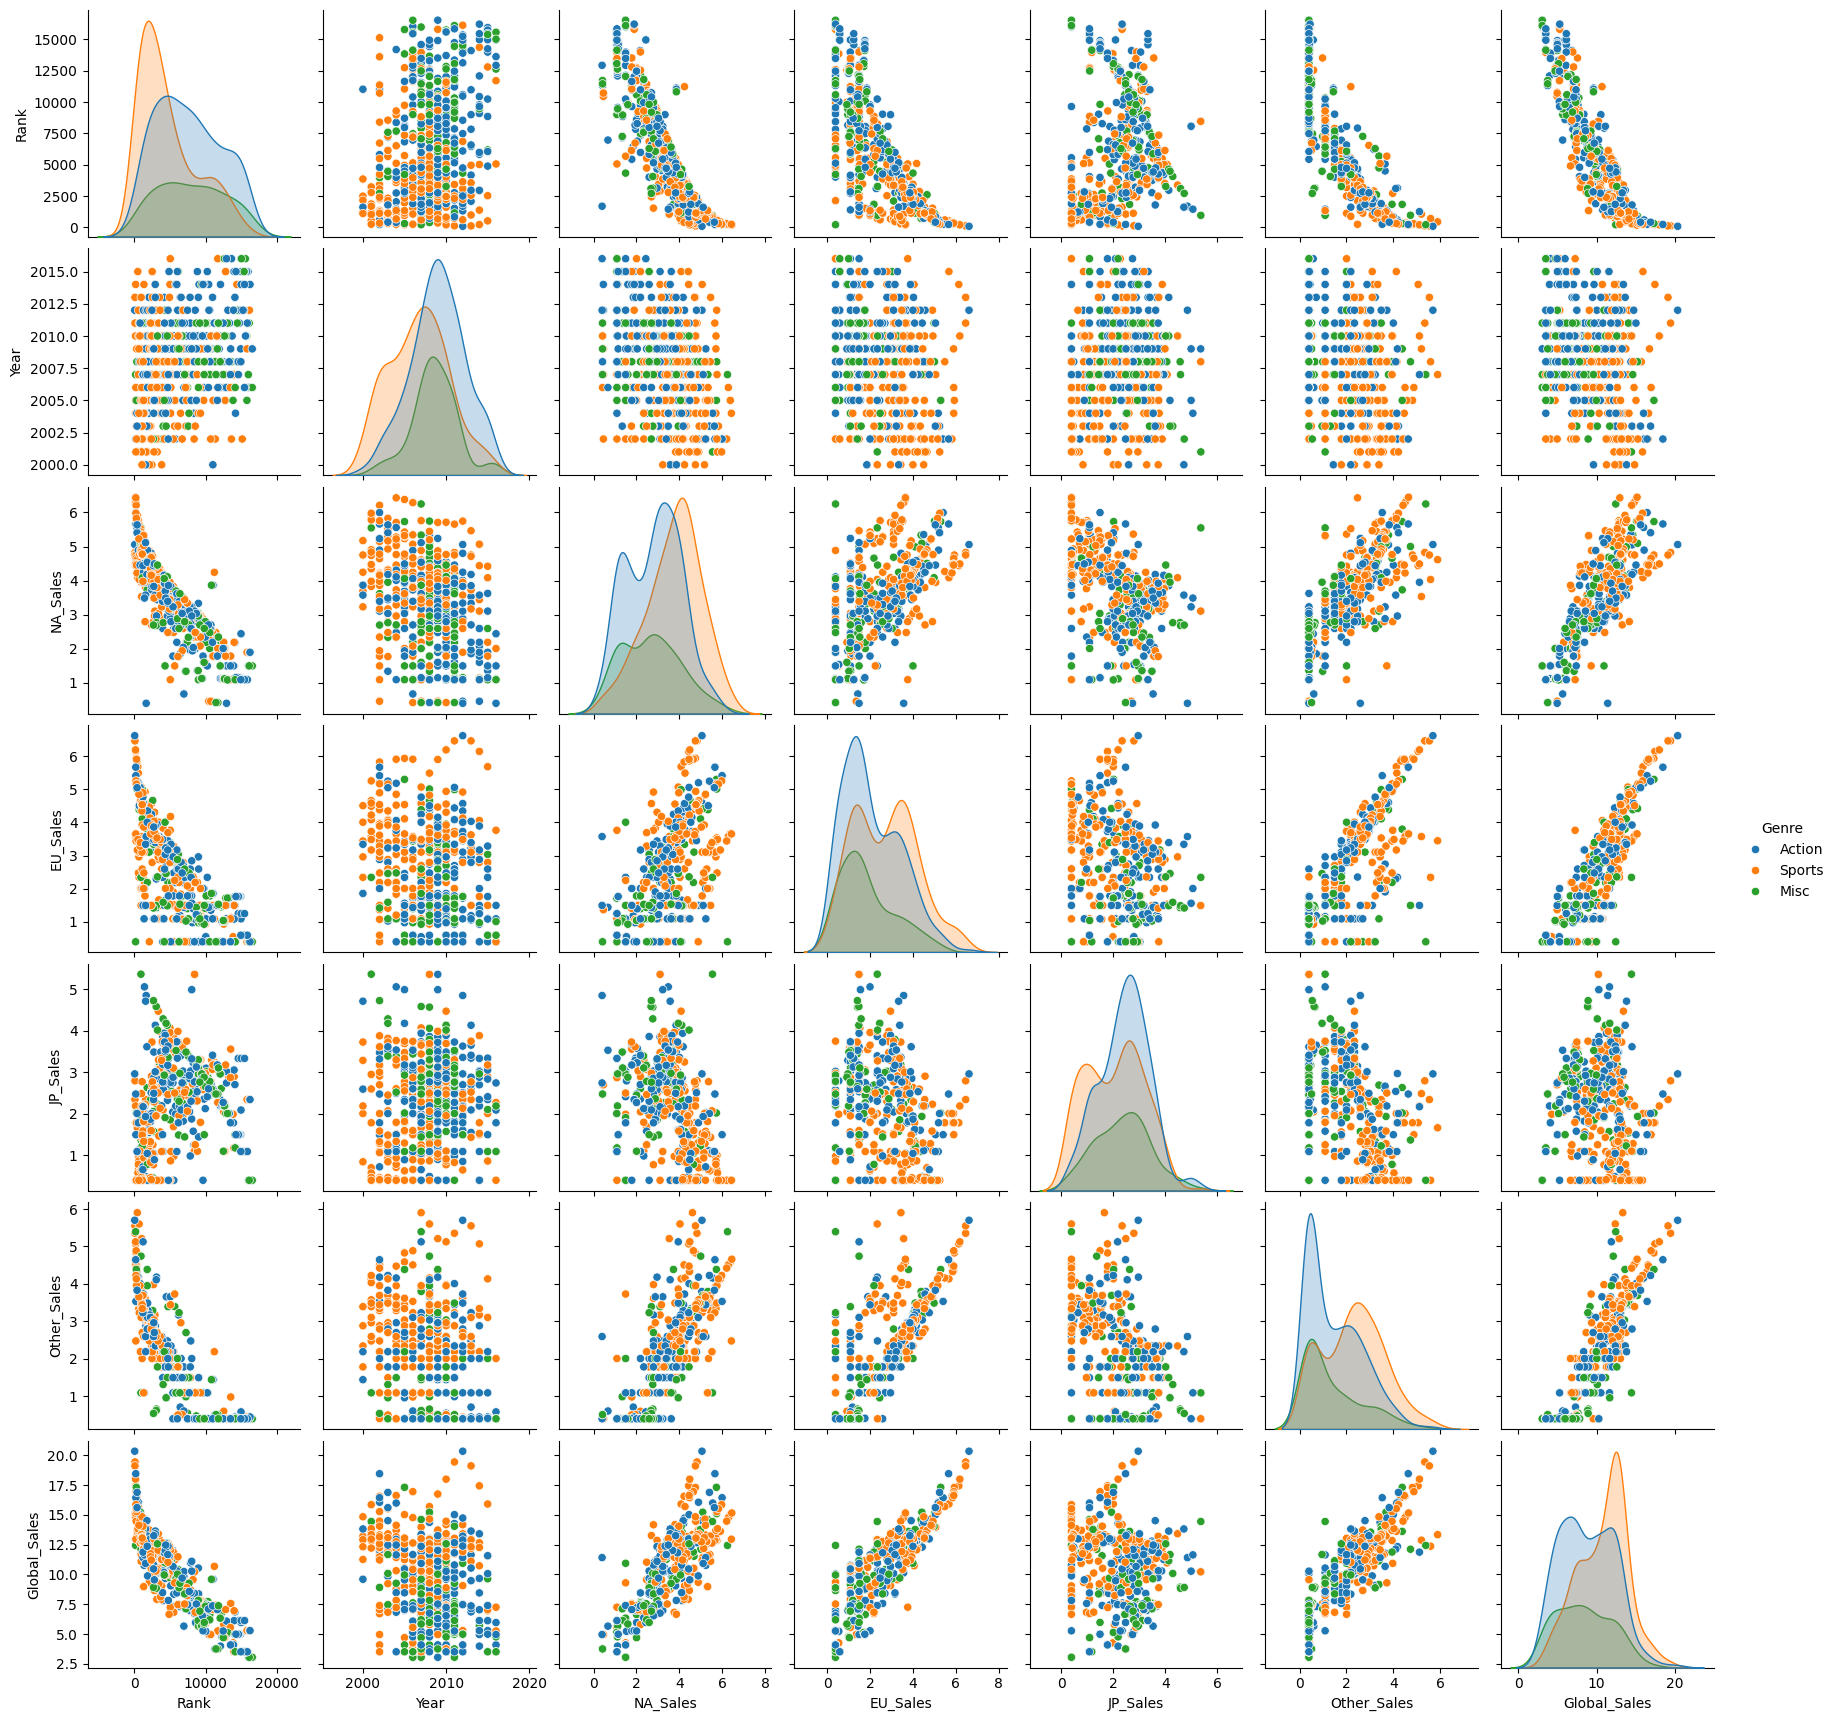

In [26]:
sns.pairplot(data = top3_data, hue = 'Genre')
plt.show()

Notice that,

- It is **like a scatter plot of video games with `hue='Genre'`**
- But it is **plotted between every pair of attributes**.
- **Color Legends** for each genre category are given on the **right side**.

Diagonal plots are different from scatter plots because x and y axis have same attribute.

Diagonal plots show a univariate curve category-wise for each attribute.

# Real-world Bad Chart Makeover

**Objectives**
- Identify and fix common chart design problems.
- Produce publication-quality charts with annotations and accessible colors.
- Export high-resolution assets for slides/reports.


In [29]:
# Setup: imports and plotting defaults
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# Matplotlib defaults for clarity in colab
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.right': False,
    'axes.spines.top': False,
    'font.size': 11,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

# Create an output directory for exports
out_dir = Path('/content/chart_exports')
out_dir.mkdir(parents=True, exist_ok=True)

## Business scenario (context)
We are the analytics team for a retail company. The head of merchandising reviews monthly dashboards for three regions (North, South, West) across 12 months. We need to monitor **sales**, **returns**, and **promotional spend**. Bad charts have caused over-ordering and missed promotion optimization.

Below, we create a realistic synthetic dataset to reproduce the scenario.


In [32]:
np.random.seed(42)
months = pd.date_range('2024-01-01', periods=12, freq= 'M')
regions = ['North', 'South', 'West']

rows = []
for r in regions:
  base = {'North': 400, 'South': 300, 'West': 220}[r]
  for m in months:
    sales = max(0, np.random.normal(base + (m.month - 1) * 12, 40))
    returns = max(0, np.random.normal(sales * 0.06, 8))
    promo = np.random.choice([0, 500, 1500], p=(0.6, 0.25, 0.15)) # occasional promotions
    rows.append({'month': m, 'region': r, 'sales': round(sales, 2), 'returns': round(returns, 2), 'promo_spend': promo})

df = pd.DataFrame(rows)
df['month_str'] = df['month'].dt.strftime('%b')
df.head(8)

/tmp/ipykernel_2437/3255496026.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range('2024-01-01', periods=12, freq= 'M')


,month,region,sales,returns,promo_spend,month_str
0,2024-01-31,North,419.87,24.09,500,Jan
1,2024-02-29,North,367.52,24.60,0,Feb
2,2024-03-31,North,487.17,35.37,0,Mar
3,2024-04-30,North,412.76,20.56,0,Apr
4,2024-05-31,North,457.68,12.15,0,May
5,2024-06-30,North,492.66,17.37,0,Jun
6,2024-07-31,North,435.68,14.84,0,Jul
7,2024-08-31,North,458.82,32.31,0,Aug


In [39]:
# pivot for plotting convenience: monthly totals across regions
monthly_totals = df.groupby('month').agg({
    'sales': 'sum',
    'returns': 'sum',
    'promo_spend': 'sum'
}).reset_index()

monthly_totals['month_str'] = monthly_totals['month'].dt.strftime('%b')
monthly_totals

,month,sales,returns,promo_spend,month_str
0,2024-01-31,987.24,43.21,1000,Jan
1,2024-02-29,1082.47,79.75,0,Feb
2,2024-03-31,979.92,72.88,0,Mar
3,2024-04-30,907.65,45.92,0,Apr
4,2024-05-31,1046.46,58.79,0,May
5,2024-06-30,1055.87,58.19,500,Jun
6,2024-07-31,1040.26,52.00,1500,Jul
7,2024-08-31,1190.16,92.56,2000,Aug
8,2024-09-30,1131.46,70.40,3500,Sep
9,2024-10-31,1214.53,90.66,1500,Oct


### Bad Chart 1 — Truncated Y-axis bar chart
Problem: The chart truncates the y-axis (nonzero baseline) making small changes look dramatic. This can cause leadership to overreact to minor monthly changes.


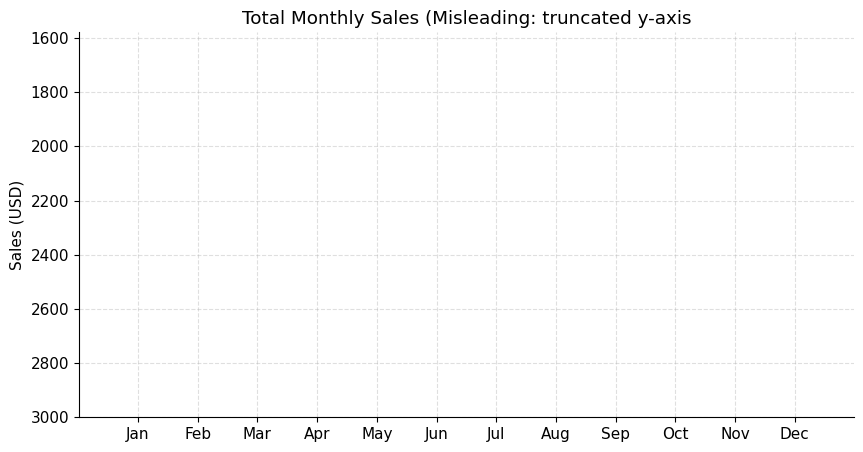

In [41]:
fig, ax = plt.subplots()
ax.bar(monthly_totals['month_str'], monthly_totals['sales'])
ax.set_title('Total Monthly Sales (Misleading: truncated y-axis')
ax.set_ylabel('Sales (USD)')
ax.set_ylim(3000, monthly_totals['sales'].max()+200) # BAD -> artificially raised min
plt.show()

### Fix 1 — Use zero baseline, add moving average and annotation
Solution steps:
1. Start y-axis at zero (unless a business-justified reason exists).
2. Show moving average to reveal trend.
3. Annotate significant months (promotions) so readers understand causes.

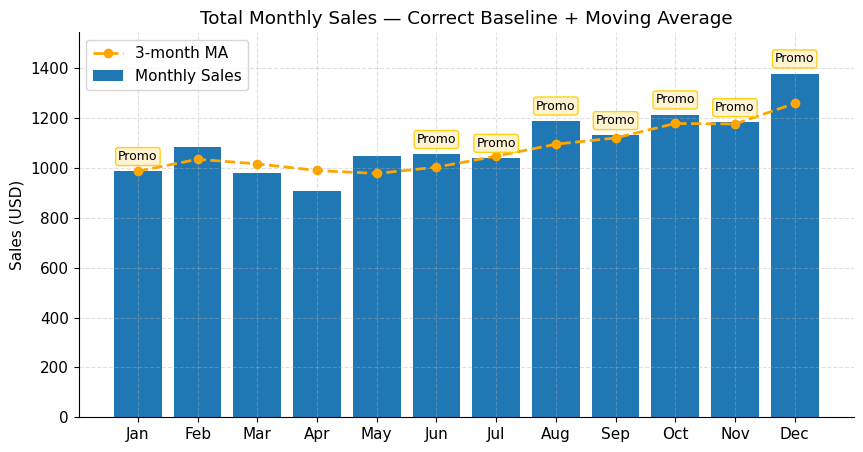

In [62]:
from ipywidgets.widgets.widget_int import Color
from matplotlib.patches import BoxStyle
from prompt_toolkit.shortcuts.progress_bar import Label
# Fix: zero baseline, moving average, annotation
fig, ax = plt.subplots()
ax.bar(monthly_totals['month_str'], monthly_totals['sales'], label = 'Monthly Sales')
# ax = sns.barplot(x = 'month_str', y = 'sales', data = monthly_totals, hue = monthly_totals['sales'], color = 'blue_r', legend='auto') --> can also use the barplot from seaborn
ax.plot(monthly_totals['month_str'], monthly_totals['sales'].rolling(3, min_periods=1).mean(),
        marker='o',color='orange', label='3-month MA', linestyle='--')

ax.set_ylim(0, monthly_totals['sales'].max()*1.12)
ax.set_ylabel("Sales (USD)")
ax.set_title("Total Monthly Sales — Correct Baseline + Moving Average")
ax.legend()

# annotate months with promotions
promo_months = monthly_totals[monthly_totals['promo_spend']>0]
for _, row in promo_months.iterrows():
  ax.annotate('Promo', (row['month_str'], row['sales']), textcoords='offset points', xytext = (0, 8),
              ha = 'center', fontsize=9, bbox = dict(boxstyle = 'round, pad = 0.2', fc = '#fff2cc', ec = '#ffcc00', alpha = 0.9))

plt.show()

### Bad Chart 2 — Overly complex stacked bar with poor color choices
Problem: Stacked bars are used with 6 categories (here: product categories simulated), with random colors and no meaningful order — hard to compare month-over-month changes for top categories.


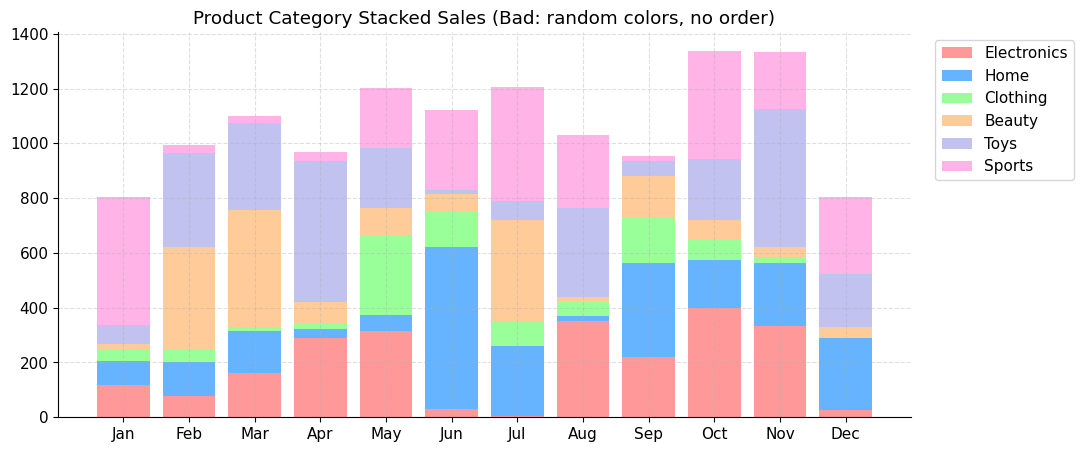

In [65]:
# creating product category breakdown (synthetic) and a bad stacked bar chart
cats = ['Electronics','Home','Clothing','Beauty','Toys','Sports'] # categories
rows = []

for m in months:
  total = np.random.uniform(800, 1400)
  shares = np.random.dirichlet(np.ones(len(cats)))

  for c, s in zip(cats, shares):
    rows. append({'month':m, 'cat':c, 'value': total * s})

cat_df = pd.DataFrame(rows)
cat_pivot = cat_df.pivot_table(index = 'month', columns='cat', values = 'value').reset_index()
cat_pivot['month_str'] = cat_pivot['month'].dt.strftime('%b')

# Bad stacked chart: random colors, no order
ig, ax = plt.subplots(figsize=(11,5))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']
bottom = np.zeros(len(cat_pivot))
for i,c in enumerate(cats):
  ax.bar(cat_pivot['month_str'], cat_pivot[c], bottom = bottom, color = colors[i], label = c)
  bottom += cat_pivot[c].values

ax.set_title("Product Category Stacked Sales (Bad: random colors, no order)")
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

### Fix 2 — Order by importance, use palette that is colorblind-friendly, optionally use hatches for print
Solution:
1. Order categories by average contribution.
2. Use a sequential palette or colorblind-friendly palette with consistent lightness.
3. Simplify the legend, break complex stacks into grouped small multiples if needed.


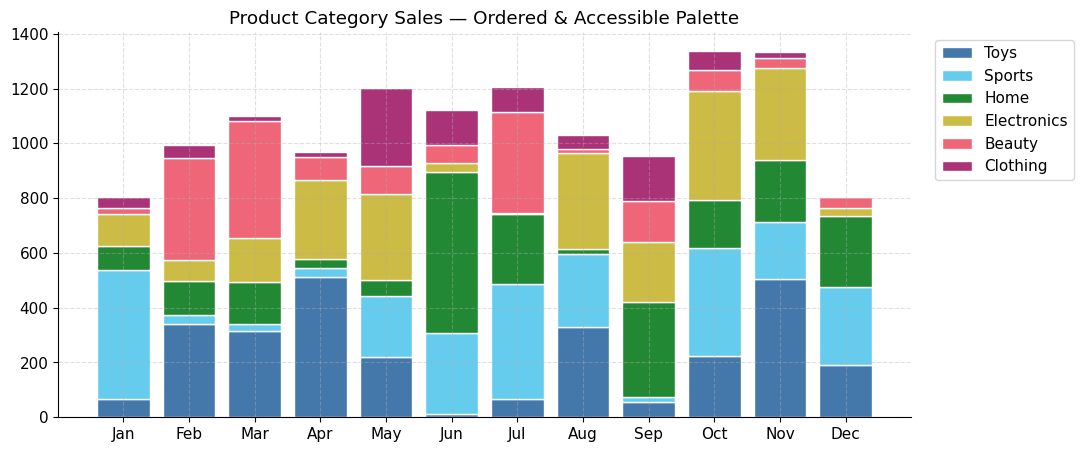

In [80]:
# Determine order by avg contribution
avg_contrib = cat_df.groupby('cat')['value'].mean().sort_values(ascending = False)
ordered_cats = avg_contrib.index.tolist()

# Plot improved stacked bars
fig, ax = plt.subplots(figsize=(11,5))
bottom = np.zeros(len(cat_pivot))

# Colorblind-friendly palette (six distinct colors)
cb_palette = ['#4477AA','#66CCEE','#228833','#CCBB44','#EE6677','#AA3377']
for i, c in enumerate(ordered_cats):
  ax.bar(cat_pivot['month_str'], cat_pivot[c], bottom = bottom, label = c, color = cb_palette[i],
         edgecolor = 'w')
  bottom += cat_pivot[c].values

ax.set_title("Product Category Sales — Ordered & Accessible Palette")
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

### Bad Chart 3 — Pie chart misuse
Problem: Pie charts hide comparisons when there are more than 3–4 slices or when values are similar.

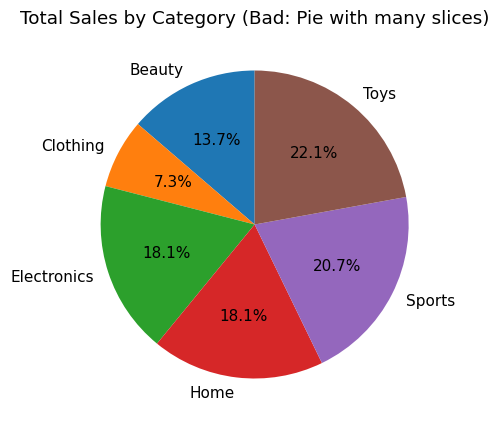

In [81]:
# Bad pie: too many categories, labels overlapping
fig, ax = plt.subplots()
sums = cat_df.groupby('cat')['value'].sum()
ax.pie(sums, labels=sums.index, autopct='%1.1f%%', startangle=90)
ax.set_title("Total Sales by Category (Bad: Pie with many slices)")
plt.show()

### Fix 3 — Replace pie with horizontal bar chart (easier to compare)
Solution: Use horizontal bars, order descending, show exact values and percentages.

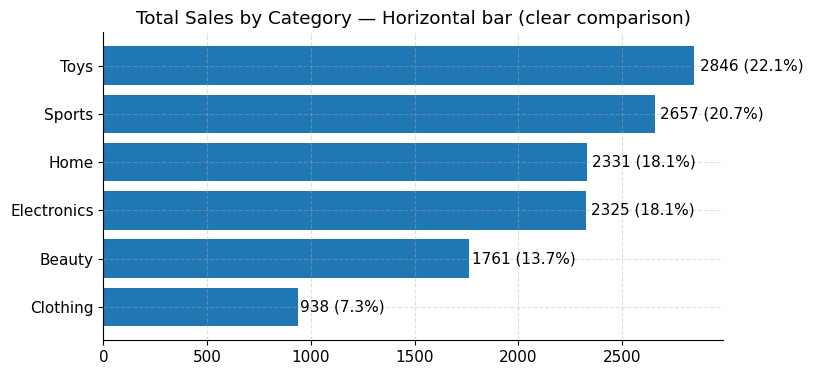

In [90]:
fig, ax = plt.subplots(figsize = (8, 4))
sums_sorted = sums.sort_values(ascending =True)
ax.barh(sums_sorted.index, sums_sorted.values)
for i, (val, name) in enumerate(zip(sums_sorted.values, sums_sorted.index)):
  ax.text(val * 1.01, i, f'{val:.0f} ({val/sums_sorted.sum() * 100:.1f}%)', va = 'center')
ax.set_title("Total Sales by Category — Horizontal bar (clear comparison)")
plt.show()

## Storytelling & action-oriented annotations
Add clear callouts for business actions: e.g., high returns in a specific month, low sales vs promo spend, reorder signals.


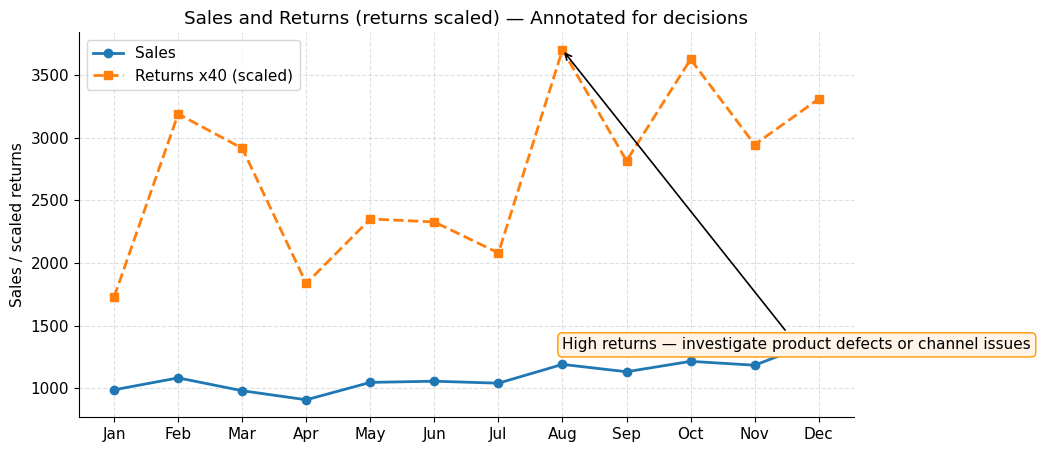

In [91]:
# Identify month with high returns / low conversion (example)
month_with_high_returns = monthly_totals.loc[monthly_totals['returns'].idxmax()]
fig, ax = plt.subplots()
ax.plot(monthly_totals['month_str'], monthly_totals['sales'], marker='o', label='Sales')
ax.plot(monthly_totals['month_str'], monthly_totals['returns']*40, marker='s', linestyle='--', label='Returns x40 (scaled)')
ax.set_title("Sales and Returns (returns scaled) — Annotated for decisions")
ax.set_ylabel("Sales / scaled returns")
ax.legend()

# Add callout
ax.annotate("High returns — investigate product defects or channel issues",
            xy=(month_with_high_returns['month'].strftime('%b'), month_with_high_returns['returns']*40),
            xytext=(month_with_high_returns['month'].strftime('%b'), month_with_high_returns['sales']+120),
            arrowprops=dict(arrowstyle="->", lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", fc="#fff4e6", ec="#ff9900"))

plt.show()


## Export: Save PNG (300 DPI) and SVG for vector use
Save final improved charts for slide decks and web reports.


Saved: /content/chart_exports/final_monthly_sales_300dpi.png /content/chart_exports/final_monthly_sales.svg


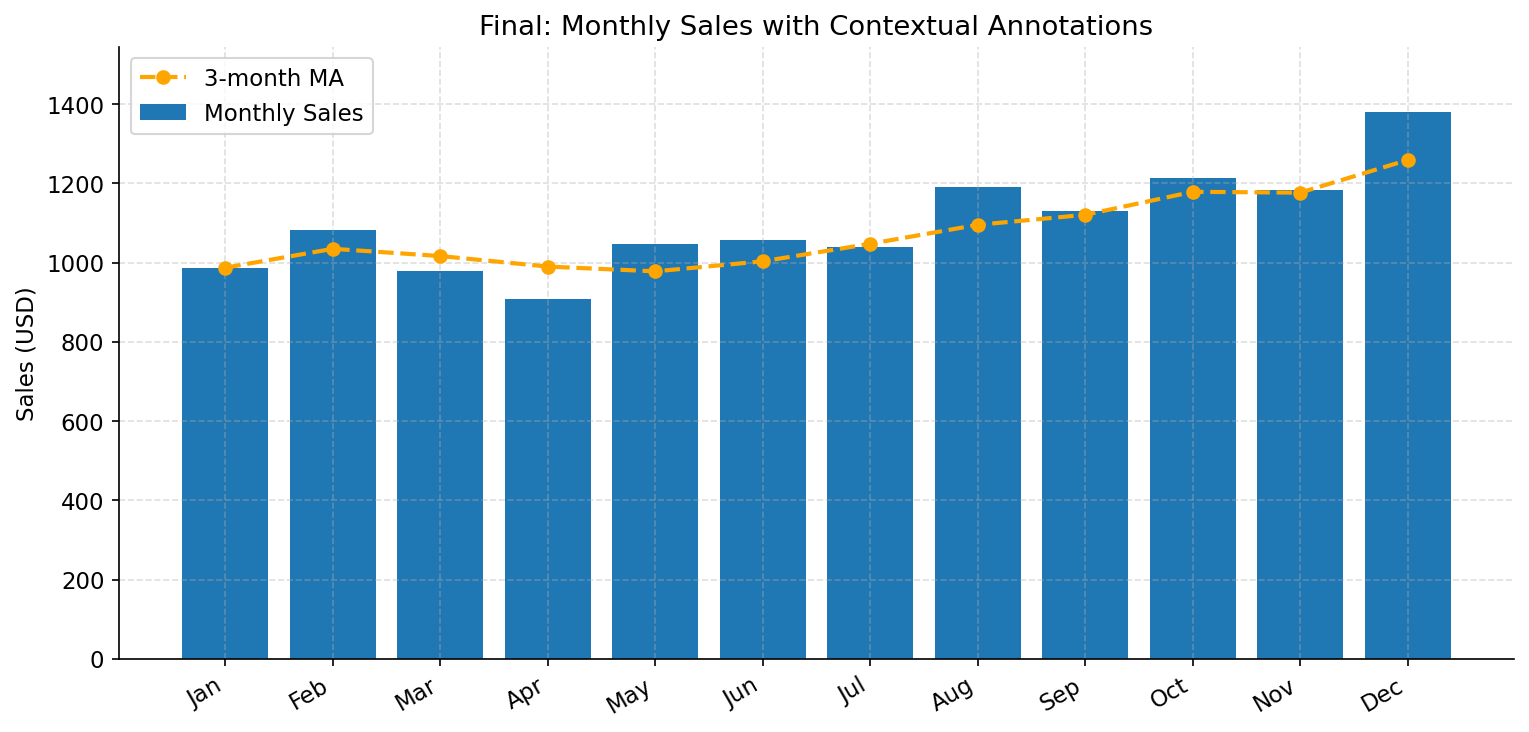

In [94]:
# Recreate a final clean chart and export
fig, ax = plt.subplots(figsize=(12,6), dpi=150)
ax.bar(monthly_totals['month_str'], monthly_totals['sales'], label='Monthly Sales')
ax.plot(monthly_totals['month_str'], monthly_totals['sales'].rolling(3, min_periods=1).mean(),
        marker='o', label='3-month MA', linestyle='--', color = 'orange')

ax.set_ylim(0, monthly_totals['sales'].max()*1.12)
ax.set_ylabel("Sales (USD)")
ax.set_title("Final: Monthly Sales with Contextual Annotations")
ax.legend()
fig.autofmt_xdate(rotation=30) # automatically format and rotate long x-axis labels

# save the figure
png_path = out_dir / 'final_monthly_sales_300dpi.png'
svg_path = out_dir / "final_monthly_sales.svg"
fig.savefig(png_path, dpi = 300, bbox_inches='tight')
fig.savefig(svg_path, bbox_inches='tight')
print("Saved:", png_path, svg_path)
plt.show()